# Self-Validating Bayesian Optimization for Cu₃VS₄ Nanoparticle Synthesis

## A System That Learns From Its Own Predictions

---

### Overview

This notebook implements a **self-validating Bayesian optimization framework** that goes beyond standard BO by:

1. **Tracking all recommendations** with prediction snapshots
2. **Learning from prediction errors** (not just adding more data)
3. **Applying bias corrections** based on historical performance
4. **Calibrating uncertainty estimates** from actual vs predicted intervals

### Key Difference from Standard BO

**Standard BO:** Train → Recommend → Add result → Retrain on data + 1 point

**This System:** Train → Recommend (store prediction) → Add result → Compare prediction vs actual → Learn systematic biases → Apply corrections to future predictions

### Data Sources

Every experiment is tagged with its source:
- `imported` — Initial dataset (your 43 experiments)
- `recommendation` — Came from model suggestion
- `manual` — You designed it yourself

### Recommendation Lifecycle

```
PENDING → User runs experiment → COMPLETED (with error analysis)
                              → SKIPPED (if not run)
```

In [36]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple, Any, Callable, Union
from datetime import datetime
from pathlib import Path
from copy import deepcopy
import json
import uuid
import warnings

# ML imports
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Statistical imports
from scipy.stats import norm, spearmanr
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube

# Import the Cu3VS4 optimizer module
import sys
sys.path.insert(0, str(Path("..").resolve()))
from cuvs_optimizer import (
    Cu3VS4Optimizer,
    raw_to_chemical_features,
    chemical_to_raw_features,
    add_chemical_features,
    compute_feature_bounds,
    expected_improvement,
    prob_in_interval,
    latin_hypercube_sample,
    calculate_objective_weights,
    RAW_FACTORS,
    CHEM_FEATURES,
    HYBRID_FEATURES,
    RAW_BOUNDS,
    OBJECTIVES,
    FEAS_COLS,
    POLYMORPH_COL,
    CUBIC_LABEL,
    CUI_MMOL,
    TOTAL_VOLUME_ML,
    DDT_MMOL_PER_ML,
    OAM_MMOL_PER_ML,
)

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✓ All imports successful!")
print("✓ Cu3VS4Optimizer loaded from cuvs_optimizer module")


✓ All imports successful!
✓ Cu3VS4Optimizer loaded from cuvs_optimizer module


---
## 1. Configuration

Set paths and system constants.

In [37]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# --- Paths ---
# Data directory (relative to notebook location)
DATA_DIR = Path("..") / "Data"
OUTPUT_DIR = Path("..") / "Outputs"

# Create directories if they don't exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# File paths
CSV_PATH = DATA_DIR / "COMPLETE_CUVS_DATA_SIDE2.csv"
EXPERIMENTS_JSON = DATA_DIR / "experiments.json"
RECOMMENDATIONS_JSON = DATA_DIR / "recommendations.json"
MODEL_STATE_JSON = DATA_DIR / "model_state.json"

# --- System Constants ---
CUI_MMOL = 0.25              # Fixed CuI amount (mmol)
TOTAL_VOLUME_ML = 12.0       # Fixed total volume (mL)
DDT_MMOL_PER_ML = 4.17       # DDT conversion (MW=202.4, ρ=0.845)
OAM_MMOL_PER_ML = 3.04       # OAm conversion (MW=267.5, ρ=0.813)

# --- Factor Definitions ---
RAW_FACTORS = ["Temp", "Time", "VOacac", "DDT", "OAm"]
OBJECTIVES = ["Size", "GSD", "Squareness"]
FEAS_COLS = ["HasProduct", "PhasePure"]
POLYMORPH_COL = "Polymorph"
CUBIC_LABEL = "cubic"

# --- Bounds ---
RAW_BOUNDS = {
    "Temp":   (260.0, 310.0),
    "Time":   (8.0, 90.0),
    "VOacac": (0.08, 0.66),
    "DDT":    (1.0, 5.0),
    "OAm":    (1.0, 7.0),
}

# --- Optimization Settings ---
N_RECOMMENDATIONS = 2  # Number of recommendations per request
MIN_COMPLETED_FOR_ERROR_MODEL = 5  # Minimum completed recs before error correction

# --- Plot Style ---
def set_publication_style():
    plt.rcParams.update({
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.figsize': (8, 5),
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.family': 'sans-serif',
    })

set_publication_style()

COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72', 
    'tertiary': '#F18F01',
    'success': '#2E8B57',
    'warning': '#E63946',
    'neutral': '#6C757D',
    'pending': '#F4A261',
    'completed': '#2A9D8F',
    'skipped': '#ADB5BD',
}

print(f"✓ Configuration loaded")
print(f"  Data directory: {DATA_DIR.resolve()}")
print(f"  CSV path: {CSV_PATH}")
print(f"  Recommendations per request: {N_RECOMMENDATIONS}")

✓ Configuration loaded
  Data directory: /Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/Data
  CSV path: ../Data/COMPLETE_CUVS_DATA_SIDE2.csv
  Recommendations per request: 2


---
## ⚠️ SETUP: Module Import

This notebook imports `Cu3VS4Optimizer` from `cuvs_optimizer.py`.

**No need to run multiple notebooks!**

Just run this notebook and it will automatically load everything it needs.


---
## 1. Data Storage Classes

These classes handle persistent storage of experiments and recommendations with full source tracking.

In [38]:
# =============================================================================
# EXPERIMENT STORE
# =============================================================================

class ExperimentStore:
    """
    Manages all experiments with source tracking and JSON persistence.
    
    Each experiment has:
    - Unique ID (EXP_001, EXP_002, ...)
    - Source: 'imported', 'recommendation', or 'manual'
    - Link to recommendation ID (if source='recommendation')
    - Synthesis conditions and results
    - Timestamp
    """
    
    def __init__(self, json_path: Path = None):
        """
        Initialize experiment store.
        
        Parameters
        ----------
        json_path : Path, optional
            Path to JSON file for persistence. If None, uses default.
        """
        self.json_path = json_path or EXPERIMENTS_JSON
        self.experiments: List[Dict[str, Any]] = []
        self._next_id = 1
        
        # Try to load existing data
        if self.json_path.exists():
            self.load()
        
    def _generate_id(self) -> str:
        """Generate next experiment ID."""
        exp_id = f"EXP_{self._next_id:03d}"
        self._next_id += 1
        return exp_id
    
    def import_from_csv(self, csv_path: Path, source: str = 'imported') -> int:
        """
        Bulk import experiments from CSV file.
        
        Parameters
        ----------
        csv_path : Path
            Path to CSV file
        source : str
            Source tag for all imported experiments
            
        Returns
        -------
        int : Number of experiments imported
        """
        df = pd.read_csv(csv_path)
        count = 0
        
        for _, row in df.iterrows():
            exp = {
                'exp_id': self._generate_id(),
                'source': source,
                'recommendation_id': None,
                'timestamp': datetime.now().isoformat(),
                'conditions': {
                    'Temp': float(row['Temp']),
                    'Time': float(row['Time']),
                    'VOacac': float(row['VOacac']),
                    'DDT': float(row['DDT']),
                    'OAm': float(row['OAm']),
                },
                'results': {
                    'Size': float(row['Size']) if pd.notna(row.get('Size')) else None,
                    'GSD': float(row['GSD']) if pd.notna(row.get('GSD')) else None,
                    'Squareness': float(row['Squareness']) if pd.notna(row.get('Squareness')) else None,
                    'HasProduct': int(row.get('HasProduct', 0)),
                    'PhasePure': int(row.get('PhasePure', 0)),
                    'Polymorph': str(row.get('Polymorph', '')) if pd.notna(row.get('Polymorph')) else None,
                },
                'run_id_original': int(row.get('Run_ID', 0)) if pd.notna(row.get('Run_ID')) else None,
            }
            self.experiments.append(exp)
            count += 1
        
        self.save()
        return count
    
    def add_experiment(
        self,
        conditions: Dict[str, float],
        results: Dict[str, Any],
        source: str = 'manual',
        recommendation_id: str = None
    ) -> str:
        """
        Add a single experiment.
        
        Parameters
        ----------
        conditions : dict
            Synthesis conditions (Temp, Time, VOacac, DDT, OAm)
        results : dict
            Experimental results (Size, GSD, Squareness, HasProduct, PhasePure, Polymorph)
        source : str
            'imported', 'recommendation', or 'manual'
        recommendation_id : str, optional
            Link to recommendation if source='recommendation'
            
        Returns
        -------
        str : Experiment ID
        """
        exp_id = self._generate_id()
        
        exp = {
            'exp_id': exp_id,
            'source': source,
            'recommendation_id': recommendation_id,
            'timestamp': datetime.now().isoformat(),
            'conditions': {
                'Temp': float(conditions.get('Temp', 0)),
                'Time': float(conditions.get('Time', 0)),
                'VOacac': float(conditions.get('VOacac', 0)),
                'DDT': float(conditions.get('DDT', 0)),
                'OAm': float(conditions.get('OAm', 0)),
            },
            'results': {
                'Size': float(results['Size']) if results.get('Size') is not None else None,
                'GSD': float(results['GSD']) if results.get('GSD') is not None else None,
                'Squareness': float(results['Squareness']) if results.get('Squareness') is not None else None,
                'HasProduct': int(results.get('HasProduct', 0)),
                'PhasePure': int(results.get('PhasePure', 0)),
                'Polymorph': results.get('Polymorph'),
            },
        }
        
        self.experiments.append(exp)
        self.save()
        return exp_id
    
    def get_all(self) -> pd.DataFrame:
        """Return all experiments as DataFrame."""
        if not self.experiments:
            return pd.DataFrame()
        
        rows = []
        for exp in self.experiments:
            row = {
                'exp_id': exp['exp_id'],
                'source': exp['source'],
                'recommendation_id': exp.get('recommendation_id'),
                'timestamp': exp['timestamp'],
                **exp['conditions'],
                **exp['results'],
            }
            rows.append(row)
        
        return pd.DataFrame(rows)
    
    def get_by_source(self, source: str) -> pd.DataFrame:
        """Return experiments filtered by source."""
        df = self.get_all()
        if df.empty:
            return df
        return df[df['source'] == source]
    
    def get_by_id(self, exp_id: str) -> Optional[Dict]:
        """Return single experiment by ID."""
        for exp in self.experiments:
            if exp['exp_id'] == exp_id:
                return exp
        return None
    
    def get_training_data(self) -> pd.DataFrame:
        """
        Return data formatted for model training.
        Only includes experiments with HasProduct=1 AND valid measurements.
        """
        df = self.get_all()
        if df.empty:
            return df
        
        # Filter to successful experiments
        df = df[df['HasProduct'] == 1].copy()
        
        # Filter out rows with missing measurements (required for GP training)
        df = df.dropna(subset=['Size', 'GSD', 'Squareness'])
        
        # Add IsCubic column
        df['IsCubic'] = (df['Polymorph'].fillna('').str.lower().str.strip() == 'cubic').astype(int)
        
        return df
    
    def count(self) -> Dict[str, int]:
        """Return counts by source."""
        df = self.get_all()
        if df.empty:
            return {'total': 0, 'imported': 0, 'recommendation': 0, 'manual': 0}
        
        counts = df['source'].value_counts().to_dict()
        counts['total'] = len(df)
        return counts
    
    def save(self):
        """Persist to JSON file."""
        data = {
            'next_id': self._next_id,
            'experiments': self.experiments,
        }
        with open(self.json_path, 'w') as f:
            json.dump(data, f, indent=2)
    
    def load(self):
        """Load from JSON file."""
        if self.json_path.exists():
            with open(self.json_path, 'r') as f:
                data = json.load(f)
            self._next_id = data.get('next_id', 1)
            self.experiments = data.get('experiments', [])
    
    def __len__(self):
        return len(self.experiments)
    
    def __repr__(self):
        counts = self.count()
        return f"ExperimentStore({counts['total']} experiments: {counts.get('imported', 0)} imported, {counts.get('recommendation', 0)} from recs, {counts.get('manual', 0)} manual)"


print("✓ ExperimentStore class defined")

✓ ExperimentStore class defined


In [39]:
# =============================================================================
# RECOMMENDATION STORE
# =============================================================================

class RecommendationStore:
    """
    Tracks recommendation lifecycle with full prediction snapshots.
    
    Each recommendation has:
    - Unique ID (REC_001, REC_002, ...)
    - Status: 'pending', 'completed', or 'skipped'
    - Target parameters (what user asked for)
    - Suggested conditions (what model recommended)
    - Predictions at recommendation time (snapshot)
    - Actual results (when completed)
    - Computed errors (actual - predicted)
    """
    
    def __init__(self, json_path: Path = None):
        """
        Initialize recommendation store.
        
        Parameters
        ----------
        json_path : Path, optional
            Path to JSON file for persistence.
        """
        self.json_path = json_path or RECOMMENDATIONS_JSON
        self.recommendations: List[Dict[str, Any]] = []
        self._next_id = 1
        
        if self.json_path.exists():
            self.load()
    
    def _generate_id(self) -> str:
        """Generate next recommendation ID."""
        rec_id = f"REC_{self._next_id:03d}"
        self._next_id += 1
        return rec_id
    
    def save_recommendation(
        self,
        target_size: float,
        size_tolerance: float,
        conditions: Dict[str, float],
        predictions: Dict[str, float],
        rank: int = 1
    ) -> str:
        """
        Save a new recommendation with prediction snapshot.
        
        Parameters
        ----------
        target_size : float
            User's target particle size
        size_tolerance : float
            Acceptable tolerance around target
        conditions : dict
            Recommended synthesis conditions
        predictions : dict
            Model predictions at recommendation time
        rank : int
            Rank of this recommendation (1 = best)
            
        Returns
        -------
        str : Recommendation ID
        """
        rec_id = self._generate_id()
        
        rec = {
            'rec_id': rec_id,
            'status': 'pending',
            'rank': rank,
            'timestamp': datetime.now().isoformat(),
            
            # What user asked for
            'target': {
                'size': target_size,
                'tolerance': size_tolerance,
            },
            
            # What model suggested
            'conditions': {
                'Temp': float(conditions.get('Temp', 0)),
                'Time': float(conditions.get('Time', 0)),
                'VOacac': float(conditions.get('VOacac', 0)),
                'DDT': float(conditions.get('DDT', 0)),
                'OAm': float(conditions.get('OAm', 0)),
            },
            
            # Predictions at recommendation time (frozen snapshot)
            'predictions': {
                'size_mu': float(predictions.get('size_mu', 0)),
                'size_std': float(predictions.get('size_std', 0)),
                'gsd_mu': float(predictions.get('gsd_mu', 0)),
                'gsd_std': float(predictions.get('gsd_std', 0)),
                'sq_mu': float(predictions.get('sq_mu', 0)),
                'sq_std': float(predictions.get('sq_std', 0)),
                'p_feasible': float(predictions.get('p_feasible', 0)),
            },
            
            # Filled when completed
            'actual_results': None,
            'completed_timestamp': None,
            'errors': None,
            
            # Filled if skipped
            'skip_reason': None,
            'skipped_timestamp': None,
        }
        
        self.recommendations.append(rec)
        self.save()
        return rec_id
    
    def complete(
        self,
        rec_id: str,
        actual_results: Dict[str, Any]
    ) -> Dict[str, float]:
        """
        Mark recommendation as completed and compute errors.
        
        Parameters
        ----------
        rec_id : str
            Recommendation ID
        actual_results : dict
            Actual experimental results (Size, GSD, Squareness, etc.)
            
        Returns
        -------
        dict : Computed errors
        """
        rec = self.get_by_id(rec_id)
        if rec is None:
            raise ValueError(f"Recommendation {rec_id} not found")
        if rec['status'] != 'pending':
            raise ValueError(f"Recommendation {rec_id} is not pending (status: {rec['status']})")
        
        # Store actual results
        rec['actual_results'] = {
            'Size': float(actual_results['Size']) if actual_results.get('Size') is not None else None,
            'GSD': float(actual_results['GSD']) if actual_results.get('GSD') is not None else None,
            'Squareness': float(actual_results['Squareness']) if actual_results.get('Squareness') is not None else None,
            'HasProduct': int(actual_results.get('HasProduct', 0)),
            'PhasePure': int(actual_results.get('PhasePure', 0)),
            'Polymorph': actual_results.get('Polymorph'),
        }
        rec['completed_timestamp'] = datetime.now().isoformat()
        rec['status'] = 'completed'
        
        # Compute errors (only if we have actual values)
        errors = self._compute_errors(rec['predictions'], rec['actual_results'])
        rec['errors'] = errors
        
        self.save()
        return errors
    
    def _compute_errors(
        self,
        predictions: Dict[str, float],
        actual: Dict[str, Any]
    ) -> Dict[str, float]:
        """Compute prediction errors and z-scores."""
        errors = {}
        
        for prop, pred_key, std_key in [
            ('Size', 'size_mu', 'size_std'),
            ('GSD', 'gsd_mu', 'gsd_std'),
            ('Squareness', 'sq_mu', 'sq_std'),
        ]:
            actual_val = actual.get(prop)
            pred_val = predictions.get(pred_key)
            pred_std = predictions.get(std_key, 0.001)
            
            if actual_val is not None and pred_val is not None:
                error = actual_val - pred_val
                z_score = error / max(pred_std, 0.001)  # Avoid division by zero
                
                errors[f'{prop.lower()}_error'] = error
                errors[f'{prop.lower()}_z_score'] = z_score
                errors[f'{prop.lower()}_within_1sigma'] = abs(z_score) < 1.0
                errors[f'{prop.lower()}_within_2sigma'] = abs(z_score) < 2.0
        
        return errors
    
    def skip(self, rec_id: str, reason: str = None):
        """Mark recommendation as skipped."""
        rec = self.get_by_id(rec_id)
        if rec is None:
            raise ValueError(f"Recommendation {rec_id} not found")
        if rec['status'] != 'pending':
            raise ValueError(f"Recommendation {rec_id} is not pending")
        
        rec['status'] = 'skipped'
        rec['skip_reason'] = reason
        rec['skipped_timestamp'] = datetime.now().isoformat()
        self.save()
    
    def get_by_id(self, rec_id: str) -> Optional[Dict]:
        """Get recommendation by ID."""
        for rec in self.recommendations:
            if rec['rec_id'] == rec_id:
                return rec
        return None
    
    def get_pending(self) -> List[Dict]:
        """Get all pending recommendations."""
        return [r for r in self.recommendations if r['status'] == 'pending']
    
    def get_completed(self) -> List[Dict]:
        """Get all completed recommendations."""
        return [r for r in self.recommendations if r['status'] == 'completed']
    
    def get_all(self) -> List[Dict]:
        """Get all recommendations."""
        return self.recommendations
    
    def get_history_df(self) -> pd.DataFrame:
        """Return recommendation history as DataFrame."""
        if not self.recommendations:
            return pd.DataFrame()
        
        rows = []
        for rec in self.recommendations:
            row = {
                'rec_id': rec['rec_id'],
                'status': rec['status'],
                'rank': rec.get('rank', 1),
                'timestamp': rec['timestamp'],
                'target_size': rec['target']['size'],
                'target_tol': rec['target']['tolerance'],
                **{f"cond_{k}": v for k, v in rec['conditions'].items()},
                **{f"pred_{k}": v for k, v in rec['predictions'].items()},
            }
            
            if rec['actual_results']:
                row.update({f"actual_{k}": v for k, v in rec['actual_results'].items()})
            
            if rec['errors']:
                row.update(rec['errors'])
            
            rows.append(row)
        
        return pd.DataFrame(rows)
    
    def get_error_statistics(self) -> Dict[str, Any]:
        """
        Compute error statistics from completed recommendations.
        Used for calibration and bias correction.
        """
        completed = self.get_completed()
        if len(completed) < 2:
            return {'n_completed': len(completed), 'sufficient_data': False}
        
        stats = {'n_completed': len(completed), 'sufficient_data': True}
        
        for prop in ['size', 'gsd', 'squareness']:
            errors = [r['errors'].get(f'{prop}_error') for r in completed 
                     if r['errors'] and r['errors'].get(f'{prop}_error') is not None]
            z_scores = [r['errors'].get(f'{prop}_z_score') for r in completed
                       if r['errors'] and r['errors'].get(f'{prop}_z_score') is not None]
            within_1s = [r['errors'].get(f'{prop}_within_1sigma') for r in completed
                        if r['errors'] and r['errors'].get(f'{prop}_within_1sigma') is not None]
            within_2s = [r['errors'].get(f'{prop}_within_2sigma') for r in completed
                        if r['errors'] and r['errors'].get(f'{prop}_within_2sigma') is not None]
            
            if errors:
                stats[f'{prop}_mae'] = np.mean(np.abs(errors))
                stats[f'{prop}_mean_error'] = np.mean(errors)  # Systematic bias
                stats[f'{prop}_std_error'] = np.std(errors)
            
            if z_scores:
                stats[f'{prop}_mean_z'] = np.mean(np.abs(z_scores))
                # Calibration factor: if mean |z| > 1, model is overconfident
                stats[f'{prop}_calibration_factor'] = max(1.0, np.sqrt(np.mean(np.array(z_scores)**2)))
            
            if within_1s:
                stats[f'{prop}_within_1sigma_rate'] = np.mean(within_1s)  # Should be ~0.68
            if within_2s:
                stats[f'{prop}_within_2sigma_rate'] = np.mean(within_2s)  # Should be ~0.95
        
        return stats
    
    def count(self) -> Dict[str, int]:
        """Return counts by status."""
        return {
            'total': len(self.recommendations),
            'pending': len(self.get_pending()),
            'completed': len(self.get_completed()),
            'skipped': len([r for r in self.recommendations if r['status'] == 'skipped']),
        }
    
    def save(self):
        """Persist to JSON file."""
        data = {
            'next_id': self._next_id,
            'recommendations': self.recommendations,
        }
        with open(self.json_path, 'w') as f:
            json.dump(data, f, indent=2)
    
    def load(self):
        """Load from JSON file."""
        if self.json_path.exists():
            with open(self.json_path, 'r') as f:
                data = json.load(f)
            self._next_id = data.get('next_id', 1)
            self.recommendations = data.get('recommendations', [])
    
    def __repr__(self):
        counts = self.count()
        return f"RecommendationStore({counts['total']} recs: {counts['pending']} pending, {counts['completed']} completed, {counts['skipped']} skipped)"


print("✓ RecommendationStore class defined")

✓ RecommendationStore class defined


---
## 2. Error Learning System

The ErrorLearner learns from prediction errors to:
1. **Bias Correction**: Train a GP on residuals to learn systematic biases
2. **Calibration**: Adjust uncertainty estimates based on historical accuracy

This is what makes the system "self-validating" — it learns where and how it's wrong.

In [40]:
# =============================================================================
# ERROR LEARNER
# =============================================================================

class ErrorLearner:
    """
    Learns from prediction errors to improve future predictions.
    
    Two correction mechanisms:
    1. Residual Model: GP trained on (X → actual - predicted) to learn systematic biases
    2. Calibration: Multiplier for uncertainty based on historical z-scores
    
    The residual model learns things like:
    "In high-temperature regions, the base model consistently underpredicts size by 3nm"
    
    Calibration learns:
    "The model is typically overconfident, multiply std by 1.3"
    """
    
    def __init__(self, min_samples: int = MIN_COMPLETED_FOR_ERROR_MODEL):
        """
        Initialize error learner.
        
        Parameters
        ----------
        min_samples : int
            Minimum completed recommendations before error model is trained
        """
        self.min_samples = min_samples
        
        # Residual models (one per property)
        self.residual_models = {
            'Size': None,
            'GSD': None,
            'Squareness': None,
        }
        
        # Calibration factors (multiply std by this)
        self.calibration_factors = {
            'Size': 1.0,
            'GSD': 1.0,
            'Squareness': 1.0,
        }
        
        # Mean bias (simple additive correction)
        self.mean_bias = {
            'Size': 0.0,
            'GSD': 0.0,
            'Squareness': 0.0,
        }
        
        # Training data (stored for persistence)
        self.training_data = {
            'X': None,  # Conditions (scaled)
            'errors': {'Size': None, 'GSD': None, 'Squareness': None},
        }
        
        self.is_fitted = False
        self.n_training_samples = 0
        self.scaler = None  # Will be set from optimizer
    
    def fit(
        self,
        completed_recommendations: List[Dict],
        scaler: StandardScaler
    ):
        """
        Fit error models from completed recommendations.
        
        Parameters
        ----------
        completed_recommendations : list
            List of completed recommendation dicts from RecommendationStore
        scaler : StandardScaler
            Scaler for feature standardization (from optimizer)
        """
        self.scaler = scaler
        n = len(completed_recommendations)
        
        if n < self.min_samples:
            print(f"[ErrorLearner] Insufficient data: {n}/{self.min_samples} completed recommendations")
            self.is_fitted = False
            return
        
        print(f"[ErrorLearner] Fitting on {n} completed recommendations...")
        
        # Extract conditions and errors
        X_list = []
        errors = {'Size': [], 'GSD': [], 'Squareness': []}
        z_scores = {'Size': [], 'GSD': [], 'Squareness': []}
        
        for rec in completed_recommendations:
            # Get conditions
            cond = rec['conditions']
            X_list.append([cond['Temp'], cond['Time'], cond['VOacac'], cond['DDT'], cond['OAm']])
            
            # Get errors
            if rec['errors']:
                for prop in ['Size', 'GSD', 'Squareness']:
                    err = rec['errors'].get(f'{prop.lower()}_error')
                    z = rec['errors'].get(f'{prop.lower()}_z_score')
                    if err is not None:
                        errors[prop].append(err)
                    if z is not None:
                        z_scores[prop].append(z)
        
        X = np.array(X_list)
        X_scaled = scaler.transform(X)
        
        # Store training data
        self.training_data['X'] = X_scaled
        self.n_training_samples = n
        
        # Fit residual models and compute calibration
        for prop in ['Size', 'GSD', 'Squareness']:
            err_array = np.array(errors[prop])
            z_array = np.array(z_scores[prop])
            
            if len(err_array) < self.min_samples:
                print(f"  {prop}: Insufficient error data ({len(err_array)} samples)")
                continue
            
            self.training_data['errors'][prop] = err_array
            
            # Compute mean bias (simple correction)
            self.mean_bias[prop] = float(np.mean(err_array))
            
            # Compute calibration factor
            if len(z_array) >= self.min_samples:
                # If mean |z| > 0.8, model is overconfident
                rms_z = np.sqrt(np.mean(z_array**2))
                self.calibration_factors[prop] = max(1.0, rms_z)
                print(f"  {prop}: Mean bias = {self.mean_bias[prop]:.3f}, "
                      f"Calibration factor = {self.calibration_factors[prop]:.2f}")
            
            # Fit residual GP (learns spatial bias patterns)
            try:
                kernel = (
                    C(1.0, (0.01, 100.0)) * 
                    Matern(length_scale=[1.0] * X_scaled.shape[1], 
                           length_scale_bounds=(0.1, 10.0), nu=2.5) +
                    WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1.0))
                )
                gp = GaussianProcessRegressor(
                    kernel=kernel,
                    normalize_y=True,
                    n_restarts_optimizer=3,
                    random_state=42
                )
                gp.fit(X_scaled, err_array)
                self.residual_models[prop] = gp
            except Exception as e:
                print(f"  {prop}: Could not fit residual GP: {e}")
                self.residual_models[prop] = None
        
        self.is_fitted = True
        print(f"[ErrorLearner] Fitting complete")
    
    def predict_bias(self, X_scaled: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Predict bias correction for given inputs.
        
        Parameters
        ----------
        X_scaled : array
            Scaled feature array (n_samples, n_features)
            
        Returns
        -------
        dict : Bias corrections for each property
        """
        bias = {}
        
        for prop in ['Size', 'GSD', 'Squareness']:
            if self.residual_models[prop] is not None and self.is_fitted:
                # Use GP to predict spatially-varying bias
                bias[prop] = self.residual_models[prop].predict(X_scaled)
            elif self.is_fitted:
                # Fall back to mean bias
                bias[prop] = np.full(len(X_scaled), self.mean_bias[prop])
            else:
                # No correction
                bias[prop] = np.zeros(len(X_scaled))
        
        return bias
    
    def get_calibration_factor(self, prop: str) -> float:
        """Get calibration factor for a property."""
        return self.calibration_factors.get(prop, 1.0)
    
    def has_enough_data(self) -> bool:
        """Check if we have enough data for error modeling."""
        return self.n_training_samples >= self.min_samples
    
    def get_diagnostics(self) -> Dict[str, Any]:
        """Return diagnostic information about the error model."""
        return {
            'is_fitted': self.is_fitted,
            'n_training_samples': self.n_training_samples,
            'min_samples_required': self.min_samples,
            'mean_bias': self.mean_bias.copy(),
            'calibration_factors': self.calibration_factors.copy(),
            'residual_models_fitted': {
                prop: (model is not None) for prop, model in self.residual_models.items()
            },
        }
    
    def save(self, json_path: Path):
        """Save error learner state (excluding GP models which can't be serialized)."""
        data = {
            'is_fitted': self.is_fitted,
            'n_training_samples': self.n_training_samples,
            'min_samples': self.min_samples,
            'mean_bias': self.mean_bias,
            'calibration_factors': self.calibration_factors,
        }
        with open(json_path, 'w') as f:
            json.dump(data, f, indent=2)
    
    def load(self, json_path: Path):
        """Load error learner state."""
        if json_path.exists():
            with open(json_path, 'r') as f:
                data = json.load(f)
            self.is_fitted = data.get('is_fitted', False)
            self.n_training_samples = data.get('n_training_samples', 0)
            self.min_samples = data.get('min_samples', MIN_COMPLETED_FOR_ERROR_MODEL)
            self.mean_bias = data.get('mean_bias', {'Size': 0.0, 'GSD': 0.0, 'Squareness': 0.0})
            self.calibration_factors = data.get('calibration_factors', {'Size': 1.0, 'GSD': 1.0, 'Squareness': 1.0})
    
    def __repr__(self):
        if self.is_fitted:
            return f"ErrorLearner(fitted on {self.n_training_samples} samples)"
        else:
            return f"ErrorLearner(not fitted, need {self.min_samples} samples)"


print("✓ ErrorLearner class defined")

✓ ErrorLearner class defined


---
## 3. Core GP Model Components

Helper functions for building Gaussian Process models and acquisition functions.

In [41]:
# =============================================================================
# GP MODEL BUILDERS & ACQUISITION FUNCTIONS
# =============================================================================

def make_gp_regressor(n_features: int) -> GaussianProcessRegressor:
    """Create GP regressor with Matérn 5/2 ARD kernel."""
    kernel = (
        C(1.0, (0.001, 1000.0)) * 
        Matern(
            length_scale=[1.0] * n_features,
            length_scale_bounds=(0.01, 100.0),
            nu=2.5
        ) +
        WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1.0))
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=15,
        random_state=42,
        alpha=1e-10
    )


def make_gp_classifier(n_features: int) -> GaussianProcessClassifier:
    """Create GP classifier for feasibility."""
    kernel = C(1.0, (0.01, 100.0)) * Matern(
        length_scale=[1.0] * n_features,
        length_scale_bounds=(0.1, 10.0),
        nu=2.5
    )
    return GaussianProcessClassifier(
        kernel=kernel,
        n_restarts_optimizer=5,
        random_state=42,
        max_iter_predict=200
    )


def expected_improvement(
    mu: np.ndarray,
    sigma: np.ndarray,
    y_best: float,
    xi: float = 0.01,
    minimize: bool = True
) -> np.ndarray:
    """Expected Improvement acquisition function."""
    sigma = np.maximum(sigma, 1e-9)
    if minimize:
        improvement = y_best - mu - xi
    else:
        improvement = mu - y_best - xi
    z = improvement / sigma
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    return np.maximum(ei, 0.0)


def prob_in_interval(
    mu: np.ndarray,
    sigma: np.ndarray,
    target: float,
    tolerance: float
) -> np.ndarray:
    """P(target - tol ≤ Y ≤ target + tol)."""
    sigma = np.maximum(sigma, 1e-9)
    z_hi = (target + tolerance - mu) / sigma
    z_lo = (target - tolerance - mu) / sigma
    return norm.cdf(z_hi) - norm.cdf(z_lo)


def latin_hypercube_sample(
    n_samples: int,
    bounds: Dict[str, Tuple[float, float]],
    feature_order: List[str],
    seed: Optional[int] = None
) -> np.ndarray:
    """Generate LHS samples."""
    n_dims = len(feature_order)
    sampler = LatinHypercube(d=n_dims, seed=seed)
    samples = sampler.random(n=n_samples)
    lows = np.array([bounds[k][0] for k in feature_order])
    highs = np.array([bounds[k][1] for k in feature_order])
    return samples * (highs - lows) + lows


print("✓ GP builders and acquisition functions defined")

✓ GP builders and acquisition functions defined


---
## 4. Self-Validating Optimizer

The main class that integrates:
- Experiment storage with source tracking
- Recommendation lifecycle management
- Error learning and bias correction
- Corrected predictions

In [42]:
# =============================================================================
# SELF-VALIDATING OPTIMIZER
# =============================================================================

class SelfValidatingOptimizer:
    """
    Bayesian Optimization for Cu₃VS₄ synthesis with self-validation.
    
    Key Features:
    - Tracks all experiments with source (imported/recommendation/manual)
    - Stores prediction snapshots when making recommendations
    - Learns from prediction errors to correct future predictions
    - Applies bias correction and calibrated uncertainties
    
    Attributes
    ----------
    exp_store : ExperimentStore
        Manages all experiments
    rec_store : RecommendationStore
        Manages recommendation lifecycle
    error_learner : ErrorLearner
        Learns from prediction errors
    """
    
    def __init__(
        self, 
        data_dir: Path = None, 
        initialize_from_csv: bool = True,
        feature_mode: str = 'hybrid',
        base_optimizer: Any = None
    ):
        """
        Initialize the self-validating optimizer.
        
        Parameters
        ----------
        data_dir : Path, optional
            Directory for data files. Defaults to DATA_DIR.
        initialize_from_csv : bool
            If True and no experiments.json exists, import from CSV.
        feature_mode : str
            Feature mode for base optimizer: 'raw', 'chemical', or 'hybrid' (default).
            Only used if base_optimizer is None.
        base_optimizer : Cu3VS4Optimizer, optional
            Base optimizer instance to use. If None, will create one from experiment data.
            This should be a Cu3VS4Optimizer instance from the base optimization notebook.
        """
        self.data_dir = data_dir or DATA_DIR
        self.feature_mode = feature_mode
        
        # Initialize stores
        self.exp_store = ExperimentStore(self.data_dir / "experiments.json")
        self.rec_store = RecommendationStore(self.data_dir / "recommendations.json")
        self.error_learner = ErrorLearner()
        
        # Check if we need to import initial data
        if initialize_from_csv and len(self.exp_store) == 0:
            csv_path = self.data_dir / "COMPLETE_CUVS_DATA_SIDE2.csv"
            if csv_path.exists():
                n = self.exp_store.import_from_csv(csv_path, source='imported')
                print(f"Imported {n} experiments from CSV as 'imported' source")
        
        # Base optimizer (Cu3VS4Optimizer from base optimization notebook)
        # This provides the GP models, acquisition functions, etc.
        self.base_optimizer = base_optimizer
        
        # Build models if we have data
        if len(self.exp_store) > 0:
            self._build_models()
            self._update_error_learner()
        
        print(f"\n{'='*60}")
        print("SELF-VALIDATING OPTIMIZER INITIALIZED")
        print(f"{'='*60}")
        print(f"Experiments: {self.exp_store}")
        print(f"Recommendations: {self.rec_store}")
        print(f"Error Learner: {self.error_learner}")
        if self.base_optimizer is not None:
            print(f"Base Optimizer: Cu3VS4Optimizer ({self.base_optimizer.feature_mode} mode)")
        else:
            print(f"Base Optimizer: Not initialized (need data)")
    
    def _build_models(self):
        """
        Build base optimizer (Cu3VS4Optimizer) from current experiment data.
        This uses the GP models and acquisition functions from the base optimization notebook.
        """
        df_all = self.exp_store.get_all()
        df_success = self.exp_store.get_training_data()
        
        if len(df_success) < 5:
            print(f"[WARNING] Only {len(df_success)} successful experiments. Need at least 5.")
            self.base_optimizer = None
            return
        
        print(f"\nBuilding base optimizer (Cu3VS4Optimizer) on {len(df_success)} successful experiments...")
        
        # Cu3VS4Optimizer is imported from cuvs_optimizer module
        # No need to check - it's always available
        
        # Ensure dataframe has all required columns and chemical features
        # Add IsCubic if not present
        if 'IsCubic' not in df_all.columns:
            df_all['IsCubic'] = (
                df_all.get('Polymorph', pd.Series()).fillna('').astype(str).str.lower().str.strip() 
                == 'cubic'
            ).astype(int)
        
        # Add chemical features if not present (needed for Cu3VS4Optimizer)
        # Check if chemical features exist
        if 'Cu_V_ratio' not in df_all.columns:
            # Need to add chemical features - check if raw_to_chemical_features is available
            if 'raw_to_chemical_features' not in globals():
                raise RuntimeError(
                    "raw_to_chemical_features function not found. "
                    "Please run the relevant cells from the base optimization notebook first."
                )
            
            # Add chemical features
            if 'add_chemical_features' in globals():
                df_all = add_chemical_features(df_all)
            else:
                # Fallback: add manually
                chem = raw_to_chemical_features(
                    Temp=df_all['Temp'].values,
                    Time=df_all['Time'].values,
                    VOacac=df_all['VOacac'].values,
                    DDT=df_all['DDT'].values,
                    OAm=df_all['OAm'].values,
                )
                for name, values in chem.items():
                    if name != 'Temp':  # Don't duplicate Temp
                        df_all[name] = values
        
        # Create or update base optimizer
        try:
            self.base_optimizer = Cu3VS4Optimizer(
                df=df_all,
                feature_mode=self.feature_mode,
                validate=False  # Skip validation for speed (we'll validate separately if needed)
            )
            print(f"  ✓ Base optimizer created ({self.feature_mode} mode)")
            print(f"  Features: {self.base_optimizer.features}")
        except Exception as e:
            print(f"  ✗ Failed to create base optimizer: {e}")
            self.base_optimizer = None
            raise
    
    def _get_scaler(self):
        """Get scaler from base optimizer."""
        if self.base_optimizer is None:
            raise RuntimeError("Base optimizer not initialized")
        return self.base_optimizer.scaler
    
    def _update_error_learner(self):
        """Update error learner with completed recommendations."""
        completed = self.rec_store.get_completed()
        if len(completed) >= self.error_learner.min_samples:
            # Use scaler from base optimizer
            scaler = self._get_scaler() if self.base_optimizer is not None else None
            self.error_learner.fit(completed, scaler)
    
    def predict(self, X: np.ndarray, apply_correction: bool = True) -> Dict[str, np.ndarray]:
        """
        Predict properties and feasibility using base optimizer + error corrections.
        
        Parameters
        ----------
        X : array (n_samples, n_features)
            Feature values in base optimizer's feature space (raw, chemical, or hybrid)
            For raw mode: (Temp, Time, VOacac, DDT, OAm)
            For hybrid mode: includes chemical features
        apply_correction : bool
            If True, apply bias correction from error learner
            
        Returns
        -------
        dict with predictions and uncertainties
        
        Raises
        ------
        RuntimeError
            If base optimizer hasn't been built yet
        """
        # Check that base optimizer is built
        if self.base_optimizer is None:
            raise RuntimeError(
                "Base optimizer not built. Need at least 5 successful experiments with valid measurements. "
                f"Currently have {len(self.exp_store.get_training_data())} valid experiments."
            )
        
        # Get base predictions from Cu3VS4Optimizer
        preds = self.base_optimizer.predict(X)
        
        # Apply error corrections if available
        if apply_correction and self.error_learner.is_fitted:
            # Convert X to scaled space for error learner
            X_scaled = self.base_optimizer.scaler.transform(X)
            bias = self.error_learner.predict_bias(X_scaled)
            
            # Apply bias corrections
            preds['size_mu'] = preds['size_mu'] + bias['Size']
            preds['gsd_mu'] = preds['gsd_mu'] + bias['GSD']
            preds['sq_mu'] = preds['sq_mu'] + bias['Squareness']
            
            # Apply calibration factors
            preds['size_std'] = preds['size_std'] * self.error_learner.get_calibration_factor('Size')
            preds['gsd_std'] = preds['gsd_std'] * self.error_learner.get_calibration_factor('GSD')
            preds['sq_std'] = preds['sq_std'] * self.error_learner.get_calibration_factor('Squareness')
        
        # Add correction flag
        preds['correction_applied'] = apply_correction and self.error_learner.is_fitted
        
        return preds
    
    def recommend(
        self,
        target_size: float,
        size_tol: float = 2.5,
        p_size_min: float = 0.15,
        p_feas_min: float = 0.25,
        n_candidates: int = 20000,
        min_distance: float = 0.3,
        seed: Optional[int] = None
    ) -> pd.DataFrame:
        """
        Generate recommendations and store them.
        
        Parameters
        ----------
        target_size : float
            Target particle size (nm)
        size_tol : float
            Acceptable tolerance around target
        p_size_min : float
            Minimum probability of hitting target size
        p_feas_min : float
            Minimum feasibility probability
        n_candidates : int
            Number of candidate points to sample
        min_distance : float
            Minimum distance between recommendations (in scaled space)
        seed : int, optional
            Random seed for reproducibility
            
        Returns
        -------
        DataFrame with recommendations (also stored in rec_store)
        """
        # Check that base optimizer is built
        if self.base_optimizer is None:
            raise RuntimeError(
                "Cannot generate recommendations: base optimizer not built. "
                f"Need at least 5 successful experiments. "
                f"Currently have {len(self.exp_store.get_training_data())} valid experiments."
            )
        
        # Auto-skip pending recommendations for the SAME target size only
        pending = self.rec_store.get_pending()
        same_target_pending = [r for r in pending if abs(r['target']['size'] - target_size) < 0.01]
        if same_target_pending:
            print(f"[INFO] Auto-skipping {len(same_target_pending)} existing recommendations for target {target_size}nm...")
            for rec in same_target_pending:
                self.rec_store.skip(rec['rec_id'], reason=f'Superseded by new request for {target_size}nm')
        
        # Show how many other pending recommendations exist for other sizes
        other_pending = len(pending) - len(same_target_pending)
        if other_pending > 0:
            print(f"[INFO] Keeping {other_pending} pending recommendations for other target sizes")
        
        print(f"\n{'='*60}")
        print(f"GENERATING RECOMMENDATIONS")
        print(f"{'='*60}")
        print(f"Target: {target_size} ± {size_tol} nm")
        print(f"Base optimizer: {self.base_optimizer.feature_mode} mode")
        print(f"Correction applied: {self.error_learner.is_fitted}")
        
        # Use base optimizer's recommend() method to get candidates
        # This uses the GP models and acquisition functions from the base optimization notebook
        base_recs = self.base_optimizer.recommend(
            target_size=target_size,
            size_tol=size_tol,
            p_size_min=p_size_min,
            p_feas_min=p_feas_min,
            n_candidates=n_candidates,
            n_return=min(N_RECOMMENDATIONS * 3, 20),  # Get more candidates for diversity selection
            min_distance=min_distance,
            seed=seed
        )
        
        if len(base_recs) == 0:
            print("[WARNING] Base optimizer returned no recommendations. Relaxing constraints...")
            base_recs = self.base_optimizer.recommend(
                target_size=target_size,
                size_tol=size_tol * 2,
                p_size_min=0.05,
                p_feas_min=0.10,
                n_candidates=n_candidates,
                n_return=min(N_RECOMMENDATIONS * 3, 20),
                min_distance=min_distance * 0.5,
                seed=seed
            )
        
        if len(base_recs) == 0:
            raise RuntimeError("No valid recommendations found even with relaxed constraints")
        
        # Convert recommendations to feature space for predictions with corrections
        # Extract feature values from base recommendations
        # For hybrid mode, we need to reconstruct the feature array
        feature_arrays = []
        for _, row in base_recs.iterrows():
            # Get raw parameters
            raw_params = {feat: row[feat] for feat in RAW_FACTORS}
            
            # Convert to feature space based on base optimizer's mode
            if self.base_optimizer.feature_mode == 'raw':
                feat_array = np.array([[raw_params['Temp'], raw_params['Time'], 
                                      raw_params['VOacac'], raw_params['DDT'], raw_params['OAm']]])
            elif self.base_optimizer.feature_mode == 'hybrid':
                # Need chemical features
                if 'raw_to_chemical_features' not in globals():
                    raise RuntimeError("raw_to_chemical_features not available")
                chem = raw_to_chemical_features(
                    Temp=np.array([raw_params['Temp']]),
                    Time=np.array([raw_params['Time']]),
                    VOacac=np.array([raw_params['VOacac']]),
                    DDT=np.array([raw_params['DDT']]),
                    OAm=np.array([raw_params['OAm']])
                )
                feat_array = np.array([[raw_params['Temp'], raw_params['Time'], 
                                      raw_params['VOacac'], raw_params['DDT'], raw_params['OAm'],
                                      chem['Cu_V_ratio'][0], chem['Metal_Conc'][0]]])
                if 'effective_dielectric' in chem:
                    feat_array = np.append(feat_array, [[chem['effective_dielectric'][0]]], axis=1)
            else:  # chemical mode
                chem = raw_to_chemical_features(
                    Temp=np.array([raw_params['Temp']]),
                    Time=np.array([raw_params['Time']]),
                    VOacac=np.array([raw_params['VOacac']]),
                    DDT=np.array([raw_params['DDT']]),
                    OAm=np.array([raw_params['OAm']])
                )
                feat_array = np.array([[chem['Cu_V_ratio'][0], chem['S_Metal_ratio'][0],
                                      chem['Ligand_Metal_ratio'][0], chem['Metal_Conc'][0],
                                      chem['log_Time'][0]]])
            feature_arrays.append(feat_array[0])
        
        X_candidates = np.array(feature_arrays)
        
        # Get corrected predictions
        preds = self.predict(X_candidates, apply_correction=True)
        
        # Recompute acquisition with corrected predictions for final selection
        df_success = self.exp_store.get_training_data()
        gsd_best = df_success["GSD"].min()
        sq_best = df_success["Squareness"].max()
        
        # Check if expected_improvement and prob_in_interval are available
        if 'expected_improvement' not in globals() or 'prob_in_interval' not in globals():
            raise RuntimeError(
                "Acquisition functions not found. Please run cells from the base optimization notebook "
                "that define expected_improvement and prob_in_interval."
            )
        
        ei_gsd = expected_improvement(preds['gsd_mu'], preds['gsd_std'], gsd_best, minimize=True)
        ei_sq = expected_improvement(preds['sq_mu'], preds['sq_std'], sq_best, minimize=False)
        
        # Normalize
        ei_gsd_n = (ei_gsd - ei_gsd.min()) / (np.ptp(ei_gsd) + 1e-10)
        ei_sq_n = (ei_sq - ei_sq.min()) / (np.ptp(ei_sq) + 1e-10)
        
        acq_obj = (ei_gsd_n + ei_sq_n) / 2
        p_size = prob_in_interval(preds['size_mu'], preds['size_std'], target_size, size_tol)
        
        total_acq = acq_obj * p_size * preds['p_feasible']
        
        # Filter candidates
        mask = (p_size >= p_size_min) & (preds['p_feasible'] >= p_feas_min)
        
        if mask.sum() < N_RECOMMENDATIONS:
            print(f"[WARNING] Only {mask.sum()} candidates meet constraints after correction. Using top candidates...")
            # Use top candidates by acquisition value
            top_n = min(N_RECOMMENDATIONS, len(total_acq))
            top_indices = np.argsort(total_acq)[::-1][:top_n]
            mask = np.zeros(len(total_acq), dtype=bool)
            mask[top_indices] = True
        
        X_feas = X_candidates[mask]
        acq_feas = total_acq[mask]
        preds_feas = {k: v[mask] if isinstance(v, np.ndarray) else v for k, v in preds.items()}
        
        # Select diverse top candidates
        order = np.argsort(acq_feas)[::-1]
        X_scaled = self.base_optimizer.scaler.transform(X_feas)
        
        selected = []
        selected_scaled = []
        
        for idx in order:
            x = X_scaled[idx]
            if selected_scaled and np.min(cdist([x], selected_scaled)) < min_distance:
                continue
            selected.append(idx)
            selected_scaled.append(x)
            if len(selected) >= N_RECOMMENDATIONS:
                break
        
        # Build results and save to store
        rows = []
        rec_ids = []
        
        for rank, sel_idx in enumerate(selected, 1):
            # Get raw parameters from base recommendations
            base_idx = np.where(mask)[0][sel_idx]
            base_row = base_recs.iloc[base_idx]
            
            conditions = {feat: float(base_row[feat]) for feat in RAW_FACTORS}
            predictions = {
                'size_mu': float(preds_feas['size_mu'][sel_idx]),
                'size_std': float(preds_feas['size_std'][sel_idx]),
                'gsd_mu': float(preds_feas['gsd_mu'][sel_idx]),
                'gsd_std': float(preds_feas['gsd_std'][sel_idx]),
                'sq_mu': float(preds_feas['sq_mu'][sel_idx]),
                'sq_std': float(preds_feas['sq_std'][sel_idx]),
                'p_feasible': float(preds_feas['p_feasible'][sel_idx]),
            }
            
            # Save to recommendation store
            rec_id = self.rec_store.save_recommendation(
                target_size=target_size,
                size_tolerance=size_tol,
                conditions=conditions,
                predictions=predictions,
                rank=rank
            )
            rec_ids.append(rec_id)
            
            # Build row for display
            row = {
                'Rank': rank,
                'Rec_ID': rec_id,
                **{k: round(v, 3) for k, v in conditions.items()},
                'Pred_Size': round(predictions['size_mu'], 2),
                'Pred_Size_Std': round(predictions['size_std'], 2),
                'Pred_GSD': round(predictions['gsd_mu'], 3),
                'Pred_Squareness': round(predictions['sq_mu'], 3),
                'P_Feasible': round(predictions['p_feasible'], 3),
            }
            rows.append(row)
        
        result_df = pd.DataFrame(rows)
        
        print(f"\n✓ Generated {len(result_df)} recommendations (IDs: {rec_ids})")
        print(f"  These are now PENDING in the recommendation store.")
        print(f"  After running experiments, use complete_recommendation() to log results.")
        
        return result_df
    
    def complete_recommendation(
        self,
        rec_id: str,
        Size: float,
        GSD: float,
        Squareness: float,
        HasProduct: int = 1,
        PhasePure: int = 1,
        Polymorph: str = 'cubic'
    ) -> Dict[str, Any]:
        """
        Complete a recommendation with actual results.
        
        This:
        1. Computes prediction errors
        2. Adds experiment to store (source='recommendation')
        3. Updates error learner
        4. Retrains models with new data
        
        Parameters
        ----------
        rec_id : str
            Recommendation ID (e.g., 'REC_001')
        Size, GSD, Squareness : float
            Measured values
        HasProduct, PhasePure : int
            Binary flags (0 or 1)
        Polymorph : str
            'cubic', 'tetragonal', etc.
            
        Returns
        -------
        dict : Prediction errors
        """
        print(f"\n{'='*60}")
        print(f"COMPLETING RECOMMENDATION: {rec_id}")
        print(f"{'='*60}")
        
        # Get recommendation
        rec = self.rec_store.get_by_id(rec_id)
        if rec is None:
            raise ValueError(f"Recommendation {rec_id} not found")
        
        # Prepare results
        actual_results = {
            'Size': Size,
            'GSD': GSD,
            'Squareness': Squareness,
            'HasProduct': HasProduct,
            'PhasePure': PhasePure,
            'Polymorph': Polymorph,
        }
        
        # Complete in recommendation store (computes errors)
        errors = self.rec_store.complete(rec_id, actual_results)
        
        # Add to experiment store
        exp_id = self.exp_store.add_experiment(
            conditions=rec['conditions'],
            results=actual_results,
            source='recommendation',
            recommendation_id=rec_id
        )
        
        print(f"\nResults recorded:")
        print(f"  Experiment ID: {exp_id}")
        print(f"  Size: {Size} nm (predicted: {rec['predictions']['size_mu']:.2f} ± {rec['predictions']['size_std']:.2f})")
        print(f"  GSD: {GSD} (predicted: {rec['predictions']['gsd_mu']:.3f})")
        print(f"  Squareness: {Squareness} (predicted: {rec['predictions']['sq_mu']:.3f})")
        
        print(f"\nPrediction errors:")
        for key, val in errors.items():
            if 'error' in key and val is not None:
                print(f"  {key}: {val:+.3f}")
        
        # Rebuild models with new data
        print(f"\nRebuilding models with new data...")
        self._build_models()
        
        # Update error learner
        self._update_error_learner()
        
        return errors
    
    def skip_recommendation(self, rec_id: str, reason: str = None):
        """Mark a recommendation as skipped."""
        self.rec_store.skip(rec_id, reason)
        print(f"Recommendation {rec_id} marked as skipped. Reason: {reason or 'Not specified'}")
    
    def add_manual_experiment(
        self,
        Temp: float, Time: float, VOacac: float, DDT: float, OAm: float,
        Size: float, GSD: float, Squareness: float,
        HasProduct: int = 1, PhasePure: int = 1, Polymorph: str = 'cubic'
    ) -> str:
        """
        Add a manually designed experiment.
        
        Returns
        -------
        str : Experiment ID
        """
        conditions = {'Temp': Temp, 'Time': Time, 'VOacac': VOacac, 'DDT': DDT, 'OAm': OAm}
        results = {
            'Size': Size, 'GSD': GSD, 'Squareness': Squareness,
            'HasProduct': HasProduct, 'PhasePure': PhasePure, 'Polymorph': Polymorph
        }
        
        exp_id = self.exp_store.add_experiment(conditions, results, source='manual')
        
        print(f"Added manual experiment: {exp_id}")
        
        # Rebuild models and update error learner (scaler changes, so error learner must retrain)
        self._build_models()
        self._update_error_learner()
        
        return exp_id
    
    def get_pending_recommendations(self) -> pd.DataFrame:
        """Get all pending recommendations as a DataFrame."""
        pending = self.rec_store.get_pending()
        if not pending:
            print("No pending recommendations.")
            return pd.DataFrame()
        
        rows = []
        for rec in pending:
            rows.append({
                'Rec_ID': rec['rec_id'],
                'Date': rec['timestamp'][:10],
                'Target_Size': rec['target']['size'],
                'Temp': rec['conditions']['Temp'],
                'Time': rec['conditions']['Time'],
                'VOacac': rec['conditions']['VOacac'],
                'DDT': rec['conditions']['DDT'],
                'OAm': rec['conditions']['OAm'],
                'Pred_Size': f"{rec['predictions']['size_mu']:.1f} ± {rec['predictions']['size_std']:.1f}",
                'Pred_GSD': f"{rec['predictions']['gsd_mu']:.3f}",
            })
        
        return pd.DataFrame(rows)
    
    def get_model_assessment(self) -> Dict[str, Any]:
        """Get self-assessment metrics from completed recommendations."""
        stats = self.rec_store.get_error_statistics()
        stats['error_learner'] = self.error_learner.get_diagnostics()
        stats['experiment_counts'] = self.exp_store.count()
        stats['recommendation_counts'] = self.rec_store.count()
        return stats
    
    def predict_from_conditions(
        self,
        Temp: float, Time: float, VOacac: float, DDT: float, OAm: float,
        verbose: bool = True
    ) -> Dict[str, Any]:
        """
        Predict outcomes from synthesis conditions (convenience method).
        Uses base optimizer + error corrections.
        
        Parameters
        ----------
        Temp, Time, VOacac, DDT, OAm : float
            Synthesis conditions (raw parameters)
        verbose : bool
            Print detailed results
            
        Returns
        -------
        dict : Predictions with uncertainties
        """
        if self.base_optimizer is None:
            raise RuntimeError("Base optimizer not initialized")
        
        # Convert raw parameters to feature space based on base optimizer's mode
        if self.base_optimizer.feature_mode == 'raw':
            X = np.array([[Temp, Time, VOacac, DDT, OAm]])
        elif self.base_optimizer.feature_mode == 'hybrid':
            # Need chemical features
            if 'raw_to_chemical_features' not in globals():
                raise RuntimeError("raw_to_chemical_features not available")
            chem = raw_to_chemical_features(
                Temp=np.array([Temp]),
                Time=np.array([Time]),
                VOacac=np.array([VOacac]),
                DDT=np.array([DDT]),
                OAm=np.array([OAm])
            )
            feat_array = [Temp, Time, VOacac, DDT, OAm, 
                         chem['Cu_V_ratio'][0], chem['Metal_Conc'][0]]
            if 'effective_dielectric' in chem:
                feat_array.append(chem['effective_dielectric'][0])
            X = np.array([feat_array])
        else:  # chemical mode
            if 'raw_to_chemical_features' not in globals():
                raise RuntimeError("raw_to_chemical_features not available")
            chem = raw_to_chemical_features(
                Temp=np.array([Temp]),
                Time=np.array([Time]),
                VOacac=np.array([VOacac]),
                DDT=np.array([DDT]),
                OAm=np.array([OAm])
            )
            X = np.array([[chem['Cu_V_ratio'][0], chem['S_Metal_ratio'][0],
                          chem['Ligand_Metal_ratio'][0], chem['Metal_Conc'][0],
                          chem['log_Time'][0]]])
        
        preds = self.predict(X, apply_correction=True)
        
        result = {
            'conditions': {'Temp': Temp, 'Time': Time, 'VOacac': VOacac, 'DDT': DDT, 'OAm': OAm},
            'Size': (preds['size_mu'][0], preds['size_std'][0]),
            'GSD': (preds['gsd_mu'][0], preds['gsd_std'][0]),
            'Squareness': (preds['sq_mu'][0], preds['sq_std'][0]),
            'P_Product': preds['p_product'][0],
            'P_PhasePure': preds['p_pure'][0],
            'P_Cubic': preds['p_cubic'][0],
            'P_Feasible': preds['p_feasible'][0],
            'correction_applied': preds['correction_applied'],
        }
        
        if verbose:
            print(f"\n{'='*60}")
            print("PREDICTION RESULTS")
            print(f"{'='*60}")
            print(f"\nConditions:")
            print(f"  Temp: {Temp}°C, Time: {Time} min, VOacac: {VOacac} mmol")
            print(f"  DDT: {DDT} mL, OAm: {OAm} mL")
            print(f"\nBase Optimizer: {self.base_optimizer.feature_mode} mode")
            print(f"\nPredictions {'(with error correction)' if result['correction_applied'] else '(base model)'}:")
            print(f"  Size:       {result['Size'][0]:.2f} ± {result['Size'][1]:.2f} nm")
            print(f"  GSD:        {result['GSD'][0]:.3f} ± {result['GSD'][1]:.3f}")
            print(f"  Squareness: {result['Squareness'][0]:.3f} ± {result['Squareness'][1]:.3f}")
            print(f"\nFeasibility:")
            print(f"  P(Product):    {result['P_Product']:.3f}")
            print(f"  P(Phase Pure): {result['P_PhasePure']:.3f}")
            print(f"  P(Cubic):      {result['P_Cubic']:.3f}")
            print(f"  P(Feasible):   {result['P_Feasible']:.3f}")
        
        return result
    
    def print_status(self):
        """Print current system status."""
        print(f"\n{'='*60}")
        print("SYSTEM STATUS")
        print(f"{'='*60}")
        
        exp_counts = self.exp_store.count()
        rec_counts = self.rec_store.count()
        
        print(f"\nExperiments:")
        print(f"  Total: {exp_counts['total']}")
        print(f"  Imported: {exp_counts.get('imported', 0)}")
        print(f"  From recommendations: {exp_counts.get('recommendation', 0)}")
        print(f"  Manual: {exp_counts.get('manual', 0)}")
        
        print(f"\nRecommendations:")
        print(f"  Total: {rec_counts['total']}")
        print(f"  Pending: {rec_counts['pending']}")
        print(f"  Completed: {rec_counts['completed']}")
        print(f"  Skipped: {rec_counts['skipped']}")
        
        print(f"\nError Learning:")
        if self.error_learner.is_fitted:
            diag = self.error_learner.get_diagnostics()
            print(f"  Status: ACTIVE (trained on {diag['n_training_samples']} samples)")
            print(f"  Mean bias corrections:")
            for prop, bias in diag['mean_bias'].items():
                print(f"    {prop}: {bias:+.3f}")
            print(f"  Calibration factors:")
            for prop, cal in diag['calibration_factors'].items():
                print(f"    {prop}: {cal:.2f}x")
        else:
            print(f"  Status: INACTIVE (need {self.error_learner.min_samples} completed recommendations)")
            print(f"  Current: {rec_counts['completed']} completed")


print("✓ SelfValidatingOptimizer class defined")

✓ SelfValidatingOptimizer class defined


---
## 5. Visualization Functions

Functions for visualizing recommendation history, prediction accuracy, and error analysis.

In [43]:
# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_recommendation_history(optimizer: SelfValidatingOptimizer, figsize: Tuple[int, int] = (14, 6)):
    """
    Plot recommendation history showing status and prediction errors.
    
    Parameters
    ----------
    optimizer : SelfValidatingOptimizer
        The optimizer instance
    figsize : tuple
        Figure size
    """
    history_df = optimizer.rec_store.get_history_df()
    
    if history_df.empty:
        print("No recommendations to display.")
        return None
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # --- Left: Timeline with status ---
    ax1 = axes[0]
    
    status_colors = {
        'pending': COLORS['pending'],
        'completed': COLORS['completed'],
        'skipped': COLORS['skipped'],
    }
    
    for i, row in history_df.iterrows():
        color = status_colors.get(row['status'], COLORS['neutral'])
        ax1.barh(i, 1, color=color, edgecolor='black', linewidth=0.5)
        
        # Add text
        label = f"{row['rec_id']}: Target {row['target_size']:.0f}nm"
        if row['status'] == 'completed' and 'size_error' in row and pd.notna(row.get('size_error')):
            label += f" (err: {row['size_error']:+.1f})"
        ax1.text(0.5, i, label, ha='center', va='center', fontsize=9, fontweight='bold')
    
    ax1.set_yticks(range(len(history_df)))
    ax1.set_yticklabels([f"{row['timestamp'][:10]}" for _, row in history_df.iterrows()])
    ax1.set_xlabel('Recommendation')
    ax1.set_title('Recommendation Timeline')
    ax1.set_xlim(0, 1)
    ax1.invert_yaxis()
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=COLORS['pending'], label='Pending'),
        Patch(facecolor=COLORS['completed'], label='Completed'),
        Patch(facecolor=COLORS['skipped'], label='Skipped'),
    ]
    ax1.legend(handles=legend_elements, loc='lower right')
    
    # --- Right: Error distribution (if any completed) ---
    ax2 = axes[1]
    completed = history_df[history_df['status'] == 'completed']
    
    if len(completed) >= 2:
        errors = completed['size_error'].dropna()
        if len(errors) > 0:
            ax2.hist(errors, bins=min(10, len(errors)), color=COLORS['primary'], 
                    edgecolor='black', alpha=0.7)
            ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect prediction')
            ax2.axvline(errors.mean(), color='orange', linestyle='-', linewidth=2, 
                       label=f'Mean error: {errors.mean():.2f}')
            ax2.set_xlabel('Size Prediction Error (nm)')
            ax2.set_ylabel('Count')
            ax2.set_title('Size Prediction Error Distribution')
            ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'Need ≥2 completed\nrecommendations\nfor error analysis', 
                ha='center', va='center', fontsize=12, transform=ax2.transAxes)
        ax2.set_title('Size Prediction Error Distribution')
    
    plt.tight_layout()
    return fig


def plot_parity(optimizer: SelfValidatingOptimizer, figsize: Tuple[int, int] = (12, 4)):
    """
    Plot predicted vs actual values for completed recommendations.
    
    Parameters
    ----------
    optimizer : SelfValidatingOptimizer
        The optimizer instance
    figsize : tuple
        Figure size
    """
    completed = optimizer.rec_store.get_completed()
    
    if len(completed) < 2:
        print(f"Need at least 2 completed recommendations for parity plots. Currently have {len(completed)}.")
        return None
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for ax, (prop, pred_key) in zip(axes, [
        ('Size', 'size_mu'),
        ('GSD', 'gsd_mu'),
        ('Squareness', 'sq_mu'),
    ]):
        predicted = []
        actual = []
        pred_std = []
        
        for rec in completed:
            if rec['actual_results'] and rec['actual_results'].get(prop) is not None:
                predicted.append(rec['predictions'][pred_key])
                actual.append(rec['actual_results'][prop])
                pred_std.append(rec['predictions'].get(pred_key.replace('_mu', '_std'), 0))
        
        if len(predicted) < 2:
            ax.text(0.5, 0.5, f'Insufficient data\nfor {prop}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(prop)
            continue
        
        predicted = np.array(predicted)
        actual = np.array(actual)
        pred_std = np.array(pred_std)
        
        # Plot with error bars
        ax.errorbar(actual, predicted, yerr=1.96*pred_std, fmt='o', 
                   color=COLORS['primary'], capsize=3, markersize=8, alpha=0.7)
        
        # Perfect prediction line
        lims = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
        margin = 0.1 * (lims[1] - lims[0])
        lims = [lims[0] - margin, lims[1] + margin]
        ax.plot(lims, lims, 'k--', lw=1, label='Perfect')
        
        # R² calculation
        if len(predicted) >= 3:
            r2 = r2_score(actual, predicted)
            mae = mean_absolute_error(actual, predicted)
            ax.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = {mae:.3f}', 
                   transform=ax.transAxes, va='top', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel(f'Actual {prop}')
        ax.set_ylabel(f'Predicted {prop}')
        ax.set_title(f'{prop} Parity')
        ax.set_aspect('equal')
        ax.legend(loc='lower right')
    
    plt.suptitle('Prediction Accuracy (Completed Recommendations Only)', y=1.02)
    plt.tight_layout()
    return fig


def plot_calibration(optimizer: SelfValidatingOptimizer, figsize: Tuple[int, int] = (10, 4)):
    """
    Plot calibration analysis: are predicted confidence intervals accurate?
    
    Parameters
    ----------
    optimizer : SelfValidatingOptimizer
        The optimizer instance
    figsize : tuple
        Figure size
    """
    completed = optimizer.rec_store.get_completed()
    
    if len(completed) < 3:
        print(f"Need at least 3 completed recommendations for calibration analysis. Have {len(completed)}.")
        return None
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # --- Left: Z-score histogram ---
    ax1 = axes[0]
    z_scores = {'Size': [], 'GSD': [], 'Squareness': []}
    
    for rec in completed:
        if rec['errors']:
            for prop in ['Size', 'GSD', 'Squareness']:
                z = rec['errors'].get(f'{prop.lower()}_z_score')
                if z is not None:
                    z_scores[prop].append(z)
    
    all_z = []
    for prop, zs in z_scores.items():
        all_z.extend(zs)
    
    if all_z:
        ax1.hist(all_z, bins=min(15, len(all_z)), color=COLORS['primary'], 
                edgecolor='black', alpha=0.7, density=True)
        
        # Overlay standard normal
        x = np.linspace(-4, 4, 100)
        ax1.plot(x, norm.pdf(x), 'r-', lw=2, label='Standard Normal\n(ideal calibration)')
        
        ax1.axvline(-1, color='orange', linestyle=':', alpha=0.7)
        ax1.axvline(1, color='orange', linestyle=':', alpha=0.7, label='±1σ bounds')
        ax1.axvline(-2, color='red', linestyle=':', alpha=0.5)
        ax1.axvline(2, color='red', linestyle=':', alpha=0.5, label='±2σ bounds')
        
        ax1.set_xlabel('Z-score (actual - predicted) / std')
        ax1.set_ylabel('Density')
        ax1.set_title('Prediction Z-Score Distribution')
        ax1.legend(fontsize=8)
    
    # --- Right: Coverage rates ---
    ax2 = axes[1]
    
    stats = optimizer.rec_store.get_error_statistics()
    
    props = ['size', 'gsd', 'squareness']
    within_1s = [stats.get(f'{p}_within_1sigma_rate', 0) * 100 for p in props]
    within_2s = [stats.get(f'{p}_within_2sigma_rate', 0) * 100 for p in props]
    
    x = np.arange(len(props))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, within_1s, width, label='Within 1σ', color=COLORS['primary'])
    bars2 = ax2.bar(x + width/2, within_2s, width, label='Within 2σ', color=COLORS['secondary'])
    
    # Target lines
    ax2.axhline(68, color='blue', linestyle='--', alpha=0.5, label='Target 1σ (68%)')
    ax2.axhline(95, color='purple', linestyle='--', alpha=0.5, label='Target 2σ (95%)')
    
    ax2.set_ylabel('Coverage Rate (%)')
    ax2.set_title('Confidence Interval Coverage')
    ax2.set_xticks(x)
    ax2.set_xticklabels(['Size', 'GSD', 'Squareness'])
    ax2.set_ylim(0, 105)
    ax2.legend(fontsize=8, loc='lower right')
    
    # Add value labels on bars
    for bar in bars1 + bars2:
        height = bar.get_height()
        if height > 0:
            ax2.annotate(f'{height:.0f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    return fig


print("✓ Visualization functions defined (history, parity, calibration)")

✓ Visualization functions defined (history, parity, calibration)


In [44]:
# =============================================================================
# MODEL ASSESSMENT & SUMMARY FUNCTIONS
# =============================================================================

def print_model_assessment(optimizer: SelfValidatingOptimizer):
    """
    Print detailed model self-assessment report.
    
    Parameters
    ----------
    optimizer : SelfValidatingOptimizer
        The optimizer instance
    """
    stats = optimizer.get_model_assessment()
    
    print("\n" + "=" * 70)
    print("MODEL SELF-ASSESSMENT REPORT")
    print("=" * 70)
    
    # Experiment counts
    exp = stats.get('experiment_counts', {})
    print(f"\n📊 EXPERIMENT DATABASE")
    print(f"   Total experiments:        {exp.get('total', 0)}")
    print(f"   ├─ Imported (initial):    {exp.get('imported', 0)}")
    print(f"   ├─ From recommendations:  {exp.get('recommendation', 0)}")
    print(f"   └─ Manual additions:      {exp.get('manual', 0)}")
    
    # Recommendation counts
    rec = stats.get('recommendation_counts', {})
    print(f"\n📋 RECOMMENDATION HISTORY")
    print(f"   Total recommendations:    {rec.get('total', 0)}")
    print(f"   ├─ Pending:               {rec.get('pending', 0)}")
    print(f"   ├─ Completed:             {rec.get('completed', 0)}")
    print(f"   └─ Skipped:               {rec.get('skipped', 0)}")
    
    # Error statistics (if available)
    if stats.get('sufficient_data', False):
        print(f"\n📈 PREDICTION ACCURACY (from {stats.get('n_completed', 0)} completed recommendations)")
        print(f"   {'Property':<12} {'MAE':>8} {'Mean Err':>10} {'Within 1σ':>10} {'Within 2σ':>10}")
        print(f"   {'-'*52}")
        
        for prop in ['size', 'gsd', 'squareness']:
            mae = stats.get(f'{prop}_mae', np.nan)
            mean_err = stats.get(f'{prop}_mean_error', np.nan)
            w1s = stats.get(f'{prop}_within_1sigma_rate', np.nan)
            w2s = stats.get(f'{prop}_within_2sigma_rate', np.nan)
            
            w1s_str = f"{w1s*100:.0f}%" if not np.isnan(w1s) else "N/A"
            w2s_str = f"{w2s*100:.0f}%" if not np.isnan(w2s) else "N/A"
            
            print(f"   {prop.capitalize():<12} {mae:>8.3f} {mean_err:>+10.3f} {w1s_str:>10} {w2s_str:>10}")
        
        print(f"\n   Target coverage: 1σ → 68%, 2σ → 95%")
        print(f"   If coverage < target → model is overconfident")
        print(f"   If coverage > target → model is underconfident")
    else:
        print(f"\n📈 PREDICTION ACCURACY")
        print(f"   Insufficient data ({stats.get('n_completed', 0)} completed, need ≥2)")
    
    # Error learner status
    el = stats.get('error_learner', {})
    print(f"\n🔧 ERROR CORRECTION STATUS")
    if el.get('is_fitted', False):
        print(f"   Status: ✅ ACTIVE (trained on {el.get('n_training_samples', 0)} samples)")
        print(f"\n   Bias Corrections (added to predictions):")
        for prop, bias in el.get('mean_bias', {}).items():
            print(f"      {prop}: {bias:+.3f}")
        print(f"\n   Calibration Factors (multiply uncertainty by):")
        for prop, cal in el.get('calibration_factors', {}).items():
            status = "⚠️ overconfident" if cal > 1.2 else "✅ well-calibrated"
            print(f"      {prop}: {cal:.2f}x {status}")
    else:
        needed = el.get('min_samples_required', 5)
        have = el.get('n_training_samples', 0)
        print(f"   Status: ⏳ INACTIVE (need {needed} completed recommendations, have {have})")
    
    print("\n" + "=" * 70)


def plot_error_learning_progress(optimizer: SelfValidatingOptimizer, figsize: Tuple[int, int] = (12, 4)):
    """
    Plot how prediction errors change over time as more recommendations are completed.
    
    Parameters
    ----------
    optimizer : SelfValidatingOptimizer
        The optimizer instance
    figsize : tuple
        Figure size
    """
    completed = optimizer.rec_store.get_completed()
    
    if len(completed) < 3:
        print(f"Need at least 3 completed recommendations. Have {len(completed)}.")
        return None
    
    # Sort by completion timestamp
    completed_sorted = sorted(completed, key=lambda x: x.get('completed_timestamp', ''))
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for ax, prop in zip(axes, ['Size', 'GSD', 'Squareness']):
        errors = []
        cumulative_mae = []
        
        for i, rec in enumerate(completed_sorted):
            if rec['errors'] and rec['errors'].get(f'{prop.lower()}_error') is not None:
                errors.append(rec['errors'][f'{prop.lower()}_error'])
                cumulative_mae.append(np.mean(np.abs(errors)))
        
        if len(errors) < 2:
            ax.text(0.5, 0.5, f'Insufficient data\nfor {prop}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{prop} Learning Progress')
            continue
        
        x = range(1, len(cumulative_mae) + 1)
        
        # Plot cumulative MAE
        ax.plot(x, cumulative_mae, 'o-', color=COLORS['primary'], markersize=6, label='Cumulative MAE')
        
        # Trend line
        if len(x) >= 3:
            z = np.polyfit(x, cumulative_mae, 1)
            p = np.poly1d(z)
            ax.plot(x, p(x), '--', color=COLORS['secondary'], alpha=0.7, 
                   label=f'Trend (slope: {z[0]:.3f})')
        
        ax.set_xlabel('# Completed Recommendations')
        ax.set_ylabel('Cumulative MAE')
        ax.set_title(f'{prop} Learning Progress')
        ax.legend(fontsize=8)
        
        # Add interpretation
        if len(cumulative_mae) >= 3 and z[0] < 0:
            ax.text(0.95, 0.95, '📉 Improving', transform=ax.transAxes, 
                   ha='right', va='top', fontsize=9, color='green')
        elif len(cumulative_mae) >= 3 and z[0] > 0.01:
            ax.text(0.95, 0.95, '📈 Degrading', transform=ax.transAxes,
                   ha='right', va='top', fontsize=9, color='red')
    
    plt.suptitle('Error Learning Progress Over Time', y=1.02)
    plt.tight_layout()
    return fig


def display_recommendations_table(recommendations_df: pd.DataFrame):
    """
    Display recommendations in a nicely formatted way.
    
    Parameters
    ----------
    recommendations_df : DataFrame
        Output from optimizer.recommend()
    """
    if recommendations_df.empty:
        print("No recommendations to display.")
        return
    
    print("\n" + "=" * 80)
    print("SYNTHESIS RECOMMENDATIONS")
    print("=" * 80)
    
    for _, row in recommendations_df.iterrows():
        print(f"\n🔬 Recommendation {row['Rank']}: {row['Rec_ID']}")
        print(f"   Conditions:")
        print(f"      Temp: {row['Temp']:.1f}°C | Time: {row['Time']:.1f} min | VOacac: {row['VOacac']:.3f} mmol")
        print(f"      DDT: {row['DDT']:.2f} mL | OAm: {row['OAm']:.2f} mL")
        print(f"   Predictions:")
        print(f"      Size: {row['Pred_Size']:.1f} ± {row['Pred_Size_Std']:.1f} nm")
        print(f"      GSD: {row['Pred_GSD']:.3f} | Squareness: {row['Pred_Squareness']:.3f}")
        print(f"   Feasibility: {row['P_Feasible']*100:.0f}%")
    
    print("\n" + "-" * 80)
    print("To complete a recommendation after running the experiment:")
    print("  optimizer.complete_recommendation('REC_XXX', Size=..., GSD=..., Squareness=...)")
    print("=" * 80)


print("✓ Assessment and utility functions defined")

✓ Assessment and utility functions defined


In [45]:
# =============================================================================
# INITIALIZE THE OPTIMIZER
# =============================================================================

# Create the self-validating optimizer
# On first run: imports 43 experiments from CSV as 'imported' source
# On subsequent runs: loads from experiments.json (preserves source tracking)

optimizer = SelfValidatingOptimizer(
    data_dir=DATA_DIR,
    initialize_from_csv=True  # Only imports if experiments.json doesn't exist
)

# Print current status
optimizer.print_status()


Building base optimizer (Cu3VS4Optimizer) on 33 successful experiments...
Building models with 8 features (hybrid mode)...
  Regression models fitted (n=33)
  HasProduct classifier fitted
  PhasePure classifier fitted
  IsCubic classifier fitted
  ✓ Base optimizer created (hybrid mode)
  Features: ['Temp', 'Time', 'VOacac', 'DDT', 'OAm', 'Cu_V_ratio', 'Metal_Conc', 'effective_dielectric']

SELF-VALIDATING OPTIMIZER INITIALIZED
Experiments: ExperimentStore(43 experiments: 43 imported, 0 from recs, 0 manual)
Recommendations: RecommendationStore(4 recs: 2 pending, 0 completed, 2 skipped)
Error Learner: ErrorLearner(not fitted, need 5 samples)
Base Optimizer: Cu3VS4Optimizer (hybrid mode)

SYSTEM STATUS

Experiments:
  Total: 43
  Imported: 43
  From recommendations: 0
  Manual: 0

Recommendations:
  Total: 4
  Pending: 2
  Completed: 0
  Skipped: 2

Error Learning:
  Status: INACTIVE (need 5 completed recommendations)
  Current: 0 completed


In [46]:
# =============================================================================
# GENERATE RECOMMENDATIONS
# =============================================================================

# Set your target particle size (nm)
TARGET_SIZE = 20.0  # <-- MODIFY THIS
SIZE_TOLERANCE = 2.5  # Acceptable range: target ± tolerance

# Generate recommendations
recommendations = optimizer.recommend(
    target_size=TARGET_SIZE,
    size_tol=SIZE_TOLERANCE,
    seed=42  # For reproducibility (remove for different results each time)
)

# Display nicely formatted
display_recommendations_table(recommendations)

# Also show as DataFrame
display(recommendations)

[INFO] Auto-skipping 2 existing recommendations for target 20.0nm...

GENERATING RECOMMENDATIONS
Target: 20.0 ± 2.5 nm
Base optimizer: hybrid mode
Correction applied: False

✓ Generated 2 recommendations (IDs: ['REC_005', 'REC_006'])
  These are now PENDING in the recommendation store.
  After running experiments, use complete_recommendation() to log results.

SYNTHESIS RECOMMENDATIONS

🔬 Recommendation 1: REC_005
   Conditions:
      Temp: 308.9°C | Time: 58.8 min | VOacac: 0.240 mmol
      DDT: 1.64 mL | OAm: 1.54 mL
   Predictions:
      Size: 18.6 ± 4.7 nm
      GSD: 1.363 | Squareness: 0.570
   Feasibility: 66%

🔬 Recommendation 2: REC_006
   Conditions:
      Temp: 309.5°C | Time: 54.3 min | VOacac: 0.373 mmol
      DDT: 1.47 mL | OAm: 1.70 mL
   Predictions:
      Size: 20.3 ± 4.4 nm
      GSD: 1.363 | Squareness: 0.568
   Feasibility: 72%

--------------------------------------------------------------------------------
To complete a recommendation after running the experiment:


,Rank,Rec_ID,Temp,Time,VOacac,DDT,OAm,Pred_Size,Pred_Size_Std,Pred_GSD,Pred_Squareness,P_Feasible
0,1,REC_005,308.884,58.767,0.240,1.636,1.538,18.61,4.72,1.363,0.570,0.662
1,2,REC_006,309.474,54.316,0.373,1.470,1.696,20.34,4.44,1.363,0.568,0.722


In [47]:
# =============================================================================
# VIEW PENDING RECOMMENDATIONS
# =============================================================================

# See what recommendations are waiting for results
pending = optimizer.get_pending_recommendations()
display(pending)

,Rec_ID,Date,Target_Size,Temp,Time,VOacac,DDT,OAm,Pred_Size,Pred_GSD
0,REC_005,2026-01-21,20.0,308.884,58.767,0.240,1.636,1.538,18.6 ± 4.7,1.363
1,REC_006,2026-01-21,20.0,309.474,54.316,0.373,1.470,1.696,20.3 ± 4.4,1.363


In [48]:
# =============================================================================
# COMPLETE A RECOMMENDATION (fill in your results)
# =============================================================================

# Uncomment and fill in when you have results:

# errors = optimizer.complete_recommendation(
#     rec_id='REC_001',      # <-- Change to your recommendation ID
#     Size=20.5,             # <-- Your measured size (nm)
#     GSD=1.25,              # <-- Your measured GSD
#     Squareness=0.65,       # <-- Your measured squareness
#     HasProduct=1,          # 1 if product formed, 0 if not
#     PhasePure=1,           # 1 if phase pure, 0 if not
#     Polymorph='cubic'      # 'cubic', 'tetragonal', 'multipod', etc.
# )

# After completing, view the model assessment:
# print_model_assessment(optimizer)

In [49]:
# =============================================================================
# MODEL SELF-ASSESSMENT
# =============================================================================

print_model_assessment(optimizer)


MODEL SELF-ASSESSMENT REPORT

📊 EXPERIMENT DATABASE
   Total experiments:        43
   ├─ Imported (initial):    43
   ├─ From recommendations:  0
   └─ Manual additions:      0

📋 RECOMMENDATION HISTORY
   Total recommendations:    6
   ├─ Pending:               2
   ├─ Completed:             0
   └─ Skipped:               4

📈 PREDICTION ACCURACY
   Insufficient data (0 completed, need ≥2)

🔧 ERROR CORRECTION STATUS
   Status: ⏳ INACTIVE (need 5 completed recommendations, have 0)



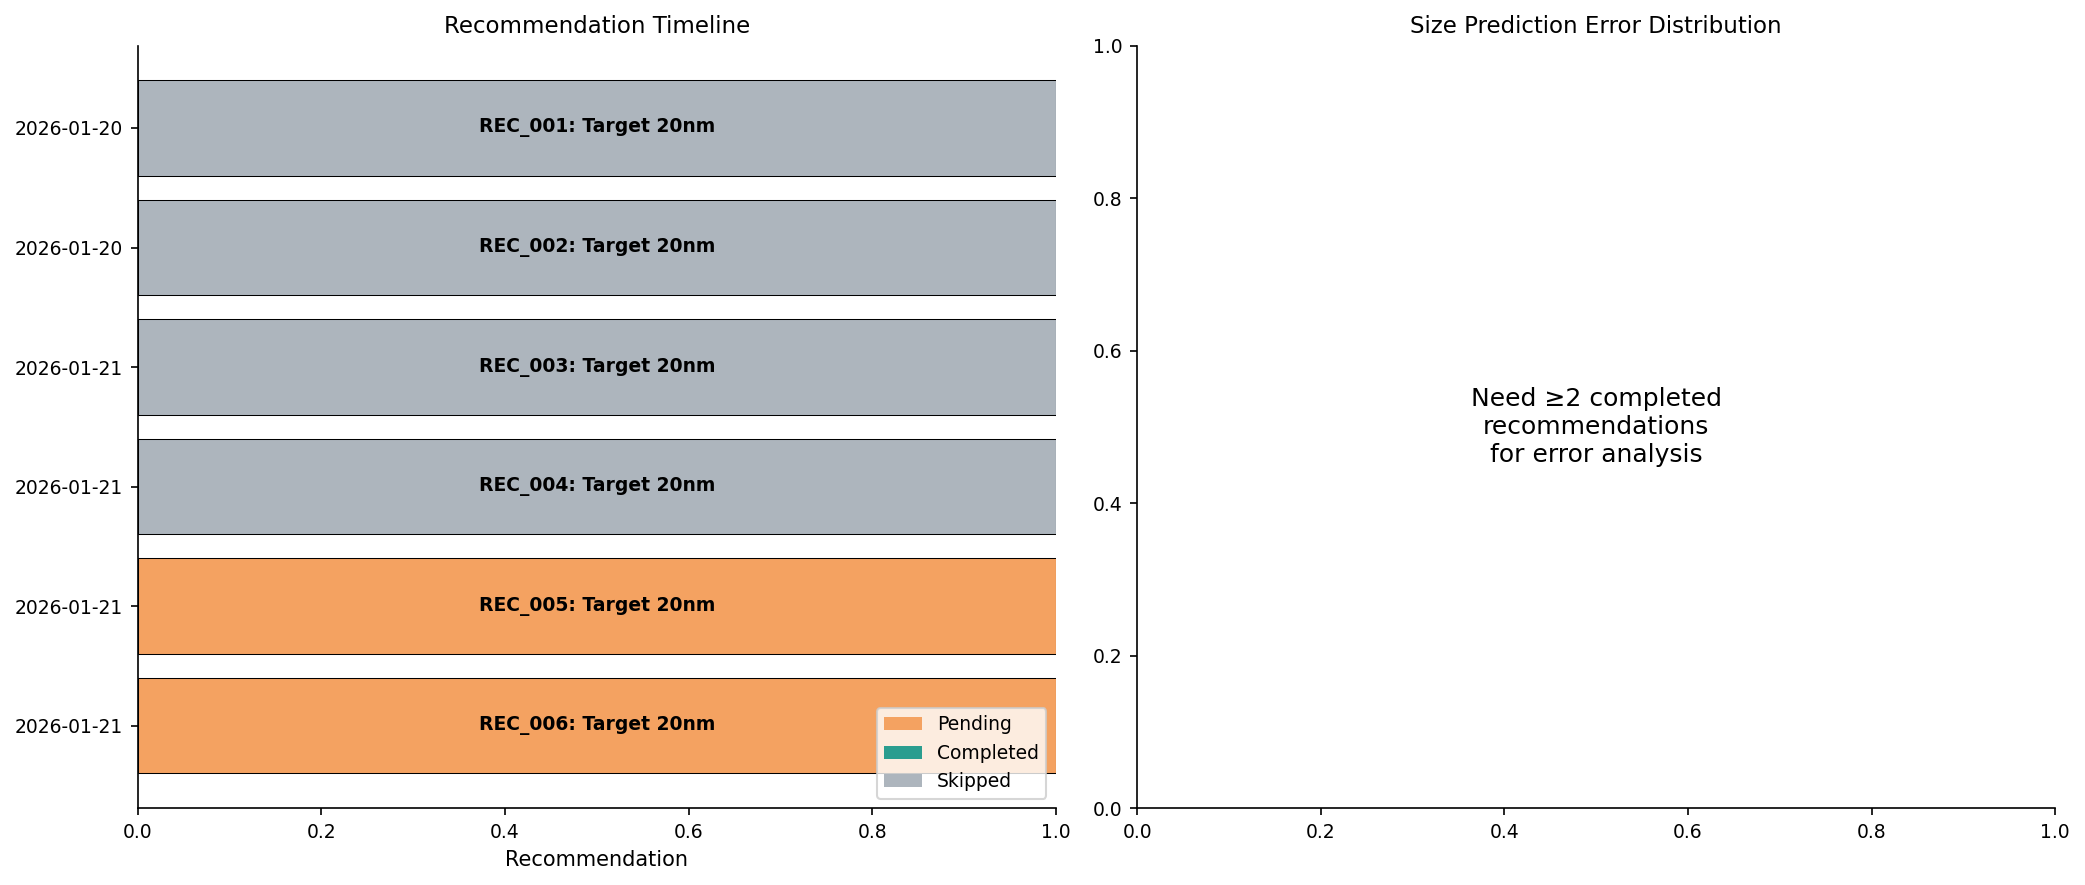

In [50]:
# =============================================================================
# VISUALIZATION: Recommendation History
# =============================================================================

fig = plot_recommendation_history(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'recommendation_history.png', dpi=300, bbox_inches='tight')
    plt.show()

In [51]:
# =============================================================================
# VISUALIZATION: Parity Plots (Predicted vs Actual)
# =============================================================================

fig = plot_parity(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'parity_plots_recommendations.png', dpi=300, bbox_inches='tight')
    plt.show()

Need at least 2 completed recommendations for parity plots. Currently have 0.


In [52]:
# =============================================================================
# VISUALIZATION: Calibration Analysis
# =============================================================================

fig = plot_calibration(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'calibration_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

Need at least 3 completed recommendations for calibration analysis. Have 0.


In [53]:
# =============================================================================
# VISUALIZATION: Error Learning Progress
# =============================================================================

fig = plot_error_learning_progress(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'learning_progress.png', dpi=300, bbox_inches='tight')
    plt.show()

Need at least 3 completed recommendations. Have 0.


In [54]:
# =============================================================================
# ADD A MANUAL EXPERIMENT (not from recommendation)
# =============================================================================

# Uncomment and fill in to add your own experiment:

# exp_id = optimizer.add_manual_experiment(
#     Temp=285.0,
#     Time=30.0,
#     VOacac=0.25,
#     DDT=3.0,
#     OAm=4.0,
#     Size=19.5,
#     GSD=1.30,
#     Squareness=0.62,
#     HasProduct=1,
#     PhasePure=1,
#     Polymorph='cubic'
# )
# print(f"Added: {exp_id}")

In [55]:
# =============================================================================
# TEST PREDICTIONS FOR SPECIFIC CONDITIONS
# =============================================================================

# Predict outcomes without making a recommendation
result = optimizer.predict_from_conditions(
    Temp=285.0,
    Time=30.0,
    VOacac=0.20,
    DDT=3.0,
    OAm=4.5,
    verbose=True
)


PREDICTION RESULTS

Conditions:
  Temp: 285.0°C, Time: 30.0 min, VOacac: 0.2 mmol
  DDT: 3.0 mL, OAm: 4.5 mL

Base Optimizer: hybrid mode

Predictions (base model):
  Size:       14.39 ± 4.32 nm
  GSD:        1.363 ± 0.194
  Squareness: 0.530 ± 0.038

Feasibility:
  P(Product):    0.878
  P(Phase Pure): 0.842
  P(Cubic):      0.873
  P(Feasible):   0.646
